# Gaia BH3

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.samplers import MCMCSampler
from exogaia.results import SamplingResults

Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST


In [3]:
np.random.seed(42)

In [4]:
epoch_astrom = EpochAstrometry(primary_mass=None, gaia_release="DR3")
epoch_astrom.retrieve_dr3_gaiabh3(exclude_outliers=True, combine_ccds=False)


----------------
Epoch astrometry
----------------

Gaia release: DR3
Reference epoch: 2016.0

---------------
Querying source
---------------

Gaia release: DR3
Source ID: 4318465066420528000

INFO: Query finished. [astroquery.utils.tap.core]

RA = 294.828 deg +/- 0.051 mas
Dec = 14.931 deg +/- 0.052 mas
Parallax = 1.644 +/- 0.069 mas
Proper motion in RA = -22.235 +/- 0.062 mas/yr
Proper motion in Dec = -155.276 +/- 0.059 mas/yr
G-band magnitude = 11.231
Pseudocolor = 1.48 um-1
1.4755152463912964 11.231087684631348

UWE = 6.18
RUWE = 3.41
Astrometric excess noise (mas) = 0.6550 +/- 0.0014
Non single star = 0

-------------------
Gaia BH3 epoch data
-------------------

Gaia release: DR3
Reference epoch: 2016.0
Source ID: 4318465066420528000

Primary mass (Msun): 0.76 +/- 0.05

Data file: /Users/tomasstolker/code/exogaia/data/gaiabh3_epochast.dat
Data shape: (599, 12)


In [5]:
print(epoch_astrom)

          transit_id  ccd_id  obs_time_tcb  centroid_pos_al  centroid_pos_error_al  parallax_factor_al  scan_pos_angle  outlier_flag  sin_scan_ang  cos_scan_ang  relative_time_year  relative_time_day
0  20114916805338633       1   2014.820290          147.066                  0.370             0.70828      -59.046727             0     -0.857587      0.514339           -1.179710        -430.889022
1  20114916805338633       2   2014.820290          146.696                  0.231             0.70828      -59.046771             0     -0.857587      0.514338           -1.179710        -430.888966
2  20114916805338633       3   2014.820290          146.685                  0.183             0.70828      -59.046816             0     -0.857588      0.514338           -1.179710        -430.888909
3  20114916805338633       4   2014.820291          146.557                  0.151             0.70828      -59.046867             0     -0.857588      0.514337           -1.179709        -430.888844


In [6]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)

In [7]:
aen = leastsq.calc_excess_noise()


------------------------
Astrometric excess noise
------------------------

Number of iterations = 4
Number of function evaluations = 12
Number of Jacobian evaluations: 6

Astrometric excess noise (mas) = 6.7798 +/- 0.0040



--------------------------
Single star (5 parameters)
--------------------------

Reduced chi^2 = 3090.339
RUWE = 30.709
F2 estimator = 701.387
Inflation factor = 55.622

Best-fit parameters:
   - RA offset = 1.506 +/- 0.053 mas
   - Dec offset = -0.033 +/- 0.050 mas
   - Parallax = 0.715 +/- 0.065 mas
   - mu in RA = -30.297 +/- 0.036 mas/yr
   - mu in Dec = -148.622 +/- 0.032 mas/yr


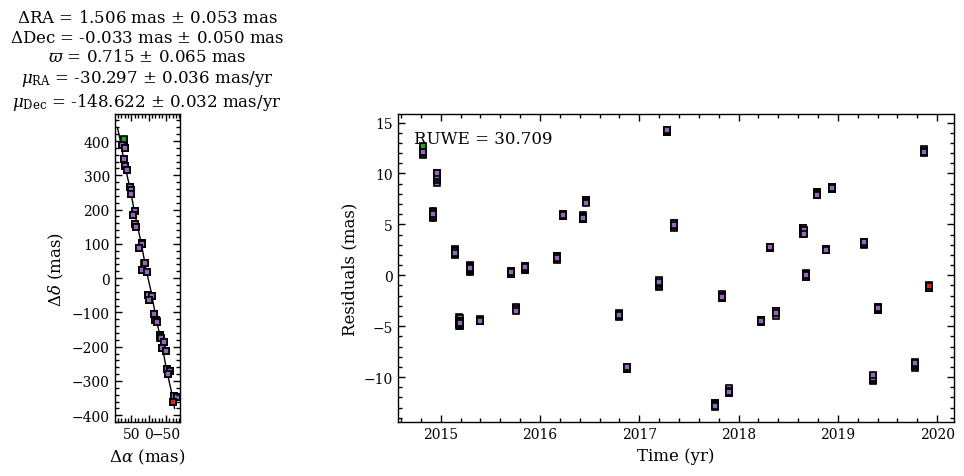

In [8]:
fig = leastsq.singl_5param(plot_file='plot.png')

In [9]:
print(leastsq)

LeastSquares(Δα = 1.50624 mas, Δδ = -0.0334119 mas, ϖ = 0.7152 mas, μ_α = -30.2968 mas/yr, μ_δ = -148.622 mas/yr)



--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 0.614

Best-fit stellar track:
   - RA offset (mas) = 4.822 +/- 0.018
   - Dec offset (mas) = 1.732 +/- 0.015
   - Parallax (mas) = 1.687 +/- 0.009
   - mu in RA (mas/yr) = -28.869 +/- 0.015
   - mu in Dec (mas/yr) = -154.238 +/- 0.013

Best-fit orbit:
   - Period (days) = 3562.248
   - Eccentricity = 0.700
   - Relative time of periastron = 0.07
   - Thiele-Innes A = 2.003 +/- 0.022
   - Thiele-Innes B = 9.670 +/- 0.025
   - Thiele-Innes F = 17.907 +/- 0.026
   - Thiele-Innes G = -15.021 +/- 0.028

Derived parameters:
   - Semi-major axis of photocenter (mas) = 23.906 +/- 0.024
   - Relative semi-major axis (au) = 14.515
   - Mass function (Msun) = 2.992e+01
   - Companion mass (Msun) = 3.139e+01

Conversion to campbell elements:
   - Period = 3562.248 days
   - Eccentricity = 0.700
   - Relative time of periastron = 0.067
   - Semi-major axis of photocenter (mas) = 23.906
   - Inclination (deg) = 110.832
   - Argument of periastron (deg) = 77.006
   - PA of ascending

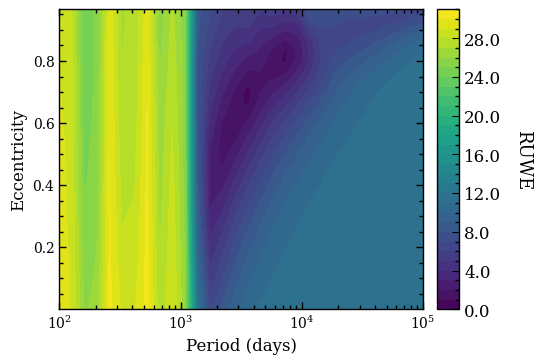

In [10]:
fig = leastsq.orbit_grid(map_type='ruwe', plot_file='plot.png', n_points=30)

In [11]:
print(leastsq)

LeastSquares(Δα = 4.82247 mas, Δδ = 1.73241 mas, ϖ = 1.68696 mas, μ_α = -28.8692 mas/yr, μ_δ = -154.238 mas/yr, P = 3562.25 days, e = 0.7, τ = 0.0666675, a = 23.9065 mas, i = 1.93438 rad, ω = 1.34401 rad, Ω = 2.36173 rad)



-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 0.515
RUWE: 0.396

Best-fit stellar track:
   - RA offset (mas) = 4.266 +/- 0.080
   - Dec offset (mas) = 2.417 +/- 0.113
   - Parallax (mas) = 1.688 +/- 0.013
   - mu in RA (mas/yr) = -28.326 +/- 0.101
   - mu in Dec (mas/yr) = -155.190 +/- 0.167

Best-fit orbit:
   - Period (days) = 4232.934 +/- 146.807
   - Eccentricity = 0.728 +/- 0.007
   - Relative time of periastron = 0.057 +/- 0.002
   - Semi-major axis of photocenter (mas) = 27.283 +/- 0.736
   - Inclination (deg) = 110.559 +/- 0.139
   - Argument of periastron (deg) = 77.835 +/- 0.221
   - PA of ascending node (deg) = 136.188 +/- 0.192
   - Jitter (mas) = 0.105 +/- 0.000

Number of function evaluations: 31
Number of Jacobian evaluations: 27

Derived parameters:
   - Relative semi-major axis (au) = 16.539
   - Mass function (Msun) = 3.146e+01
   - Companion mass (Msun) = 3.293e+01


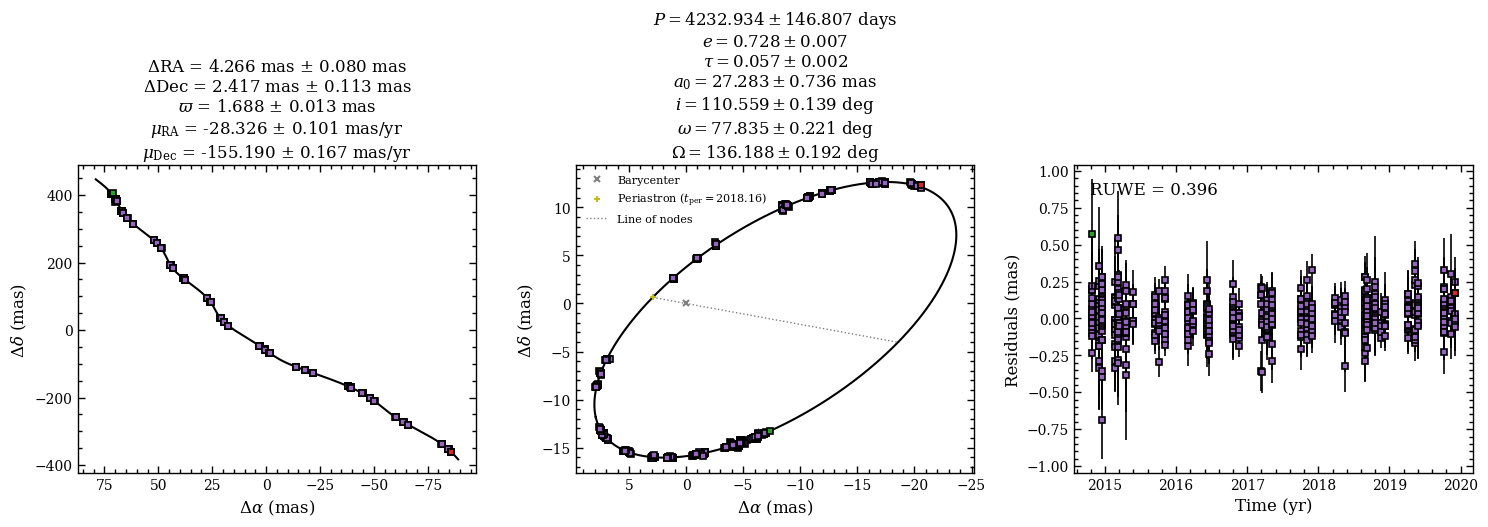

In [12]:
fig = leastsq.orbit_fit(inc_jitter=True, plot_file='plot.png')

In [13]:
print(leastsq)

LeastSquares(Δα = 4.26642 mas, Δδ = 2.41716 mas, ϖ = 1.6877 mas, μ_α = -28.3259 mas/yr, μ_δ = -155.19 mas/yr, P = 4232.93 days, e = 0.728361, τ = 0.0568079, a = 27.2834 mas, i = 1.92961 rad, ω = 1.35848 rad, Ω = 2.37693 rad)


In [14]:
sampler = MCMCSampler(epoch_astrometry=epoch_astrom, least_squares=leastsq)


------------
MCMC sampler
------------

Primary mass (Msun) = 0.76 +/- 0.05
Number of parameters: 12

Priors:
   - ra_offset -> Normal: [4.27, 0.10]
   - dec_offset -> Normal: [2.42, 0.10]
   - parallax -> Normal: [1.69, 0.10]
   - pmra -> Normal: [-28.33, 0.10]
   - pmdec -> Normal: [-155.19, 0.10]
   - per -> Normal: [4232.93, 146.81]
   - ecc -> Normal: [0.73, 0.01]
   - tau -> Normal: [0.06, 0.00]
   - sma -> Normal: [27.28, 0.74]
   - inc -> Normal: [1.93, 0.00]
   - aop -> Normal: [1.36, 0.00]
   - pan -> Normal: [2.38, 0.00]


In [15]:
sampler.run_ptmcmc(
    pickle_file="exogaia.pkl",
    n_temps=10,
    n_walkers=200,
    n_steps=1000,
    n_sweeps=1,
    progress=True,
)


-------------
Run reddemcee
-------------



100%|████████████████████████████████████████████████████████| 10000/10000 [08:37<00:00, 19.33it/s]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [57.06696436 60.09262007 52.56313592 59.13507335 60.44338677 60.18495565
 59.24177886 60.59007372 60.02827904 60.90721902 58.58101248 63.70167574]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [61.69334832 58.02831996 53.61006381 55.50916581 53.95324379 55.69630651
 58.19308878 56.99060923 54.74073242 60.24945582 60.99885778 59.24236956]
The chain is shorter than 50 times the integrated autocorrelation time for 12 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 20;
tau: [57.07569915 56.61779895 59.57930956 58.72707847 57.99421217 56.5266164
 55.5961875  55.18568375 55.6917287  59.83141

In [16]:
results = SamplingResults(burnin=500, pickle_file="exogaia.pkl")


-----------
Fit results
-----------

Number of parameters: 12
Samples shape: (10, 1000, 200, 12)

Burnin: 500
Samples shape: (10, 500, 200, 12)

Reshaped samples: (1000000, 12)



------------
Plot walkers
------------

Number of walkers: 100
Thin value: 1
Output file: plot.png


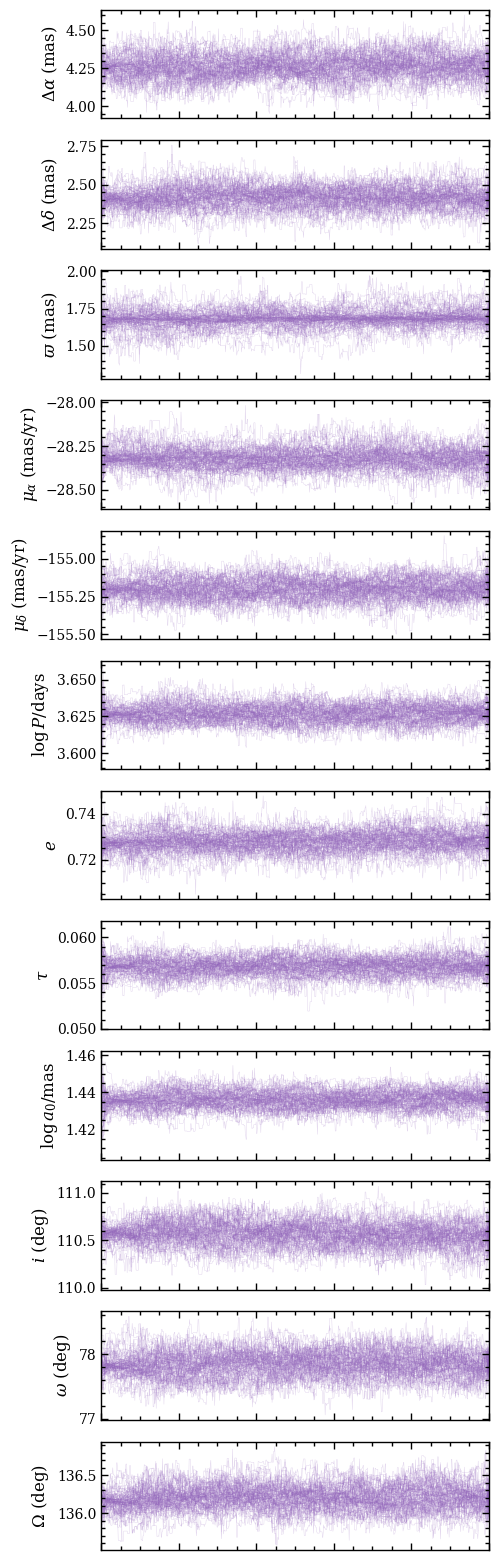

In [17]:
fig = results.plot_walkers(n_walkers=100, thin=None, plot_file="plot.png")


--------------
Plot posterior
--------------

Output file: plot.png


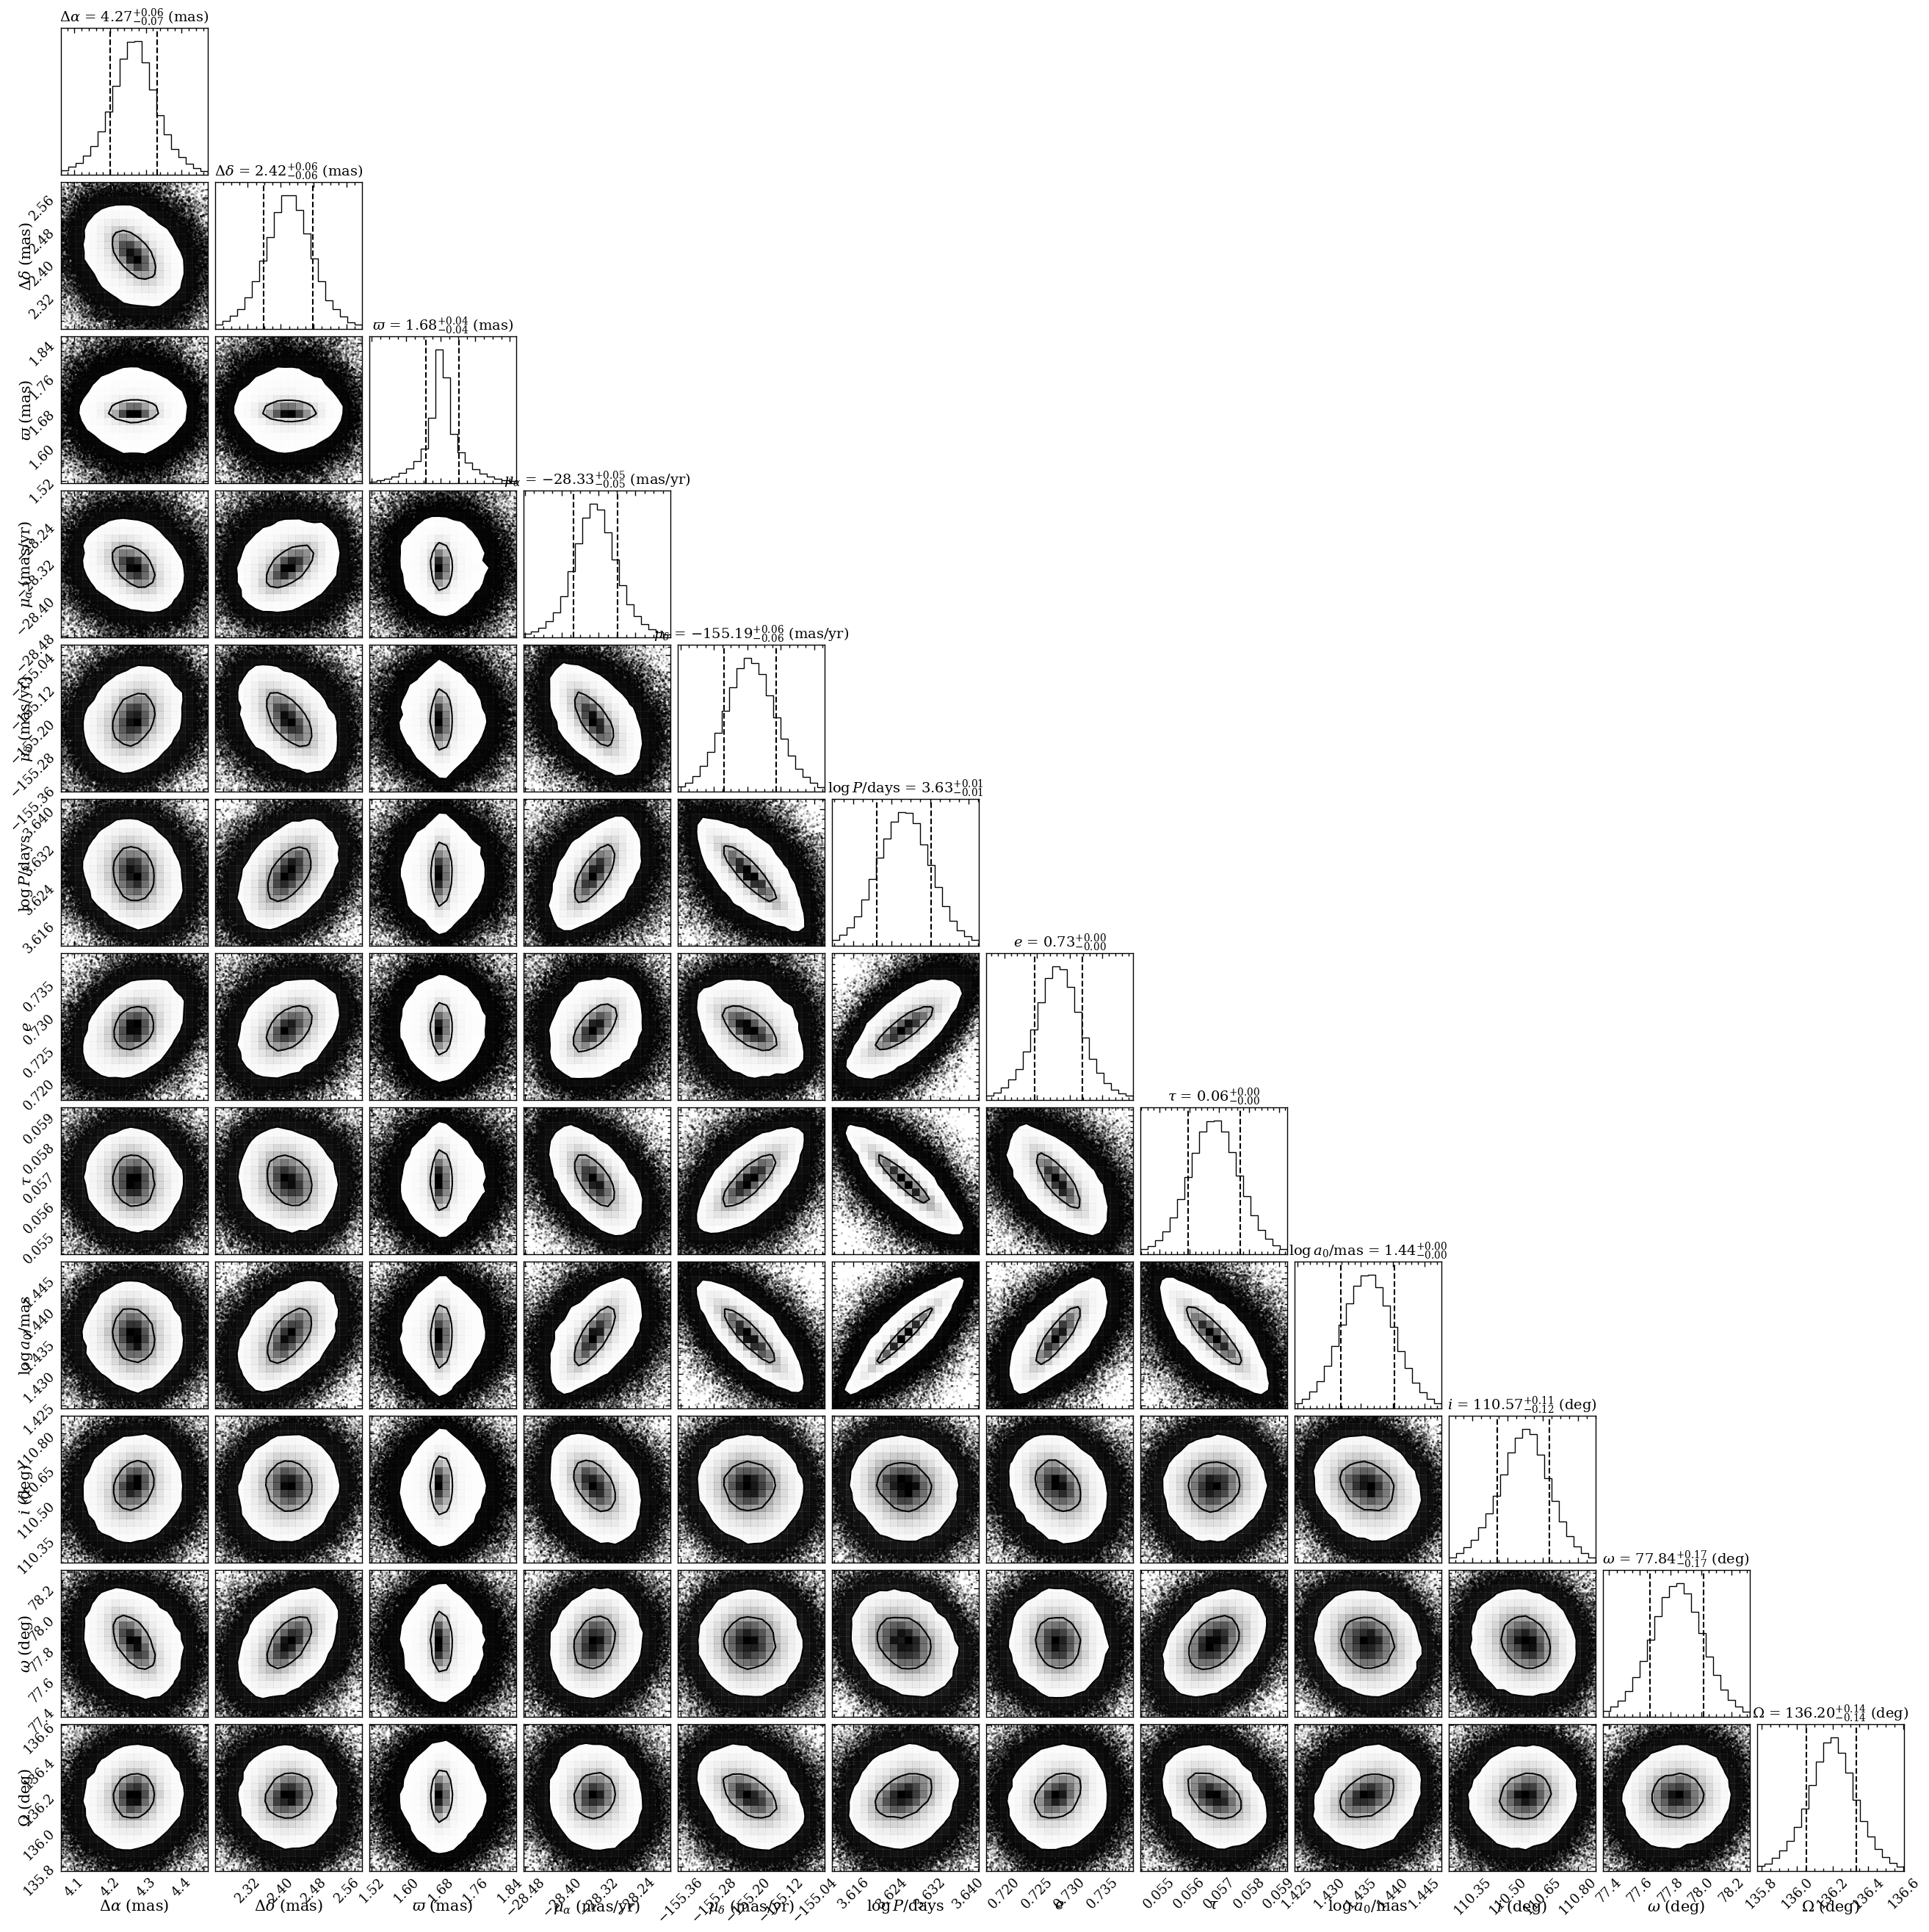

In [18]:
fig = results.plot_posterior(truths=None, plot_file="plot.png")


--------------
Plot residuals
--------------


-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 4.258
   - Dec offset (mas) = 2.427
   - Parallax (mas) = 1.681
   - Proper motion in RA (mas/yr) = -28.332
   - Proper motion in Dec (mas/yr) = -155.188

---------------------
Calculate orbit model
---------------------

Orbit parameters:
   - Period (days) = 4226.527
   - Eccentricity = 0.728
   - Relative time of periastron = 0.057
   - Semi-major axis (mas) = 27.249
   - Inclination (deg) = 110.589
   - Argument of periastron (deg) = 77.868
   - PA of ascending node (deg) = 136.203


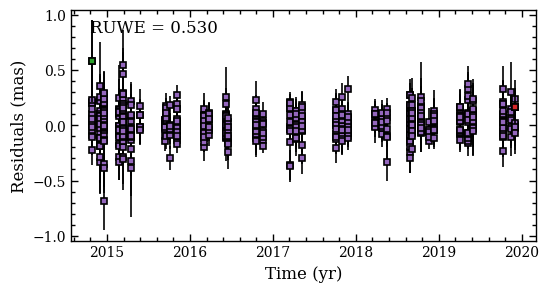

In [19]:
fig = results.plot_residuals(plot_file="plot.png")


----------
Plot orbit
----------



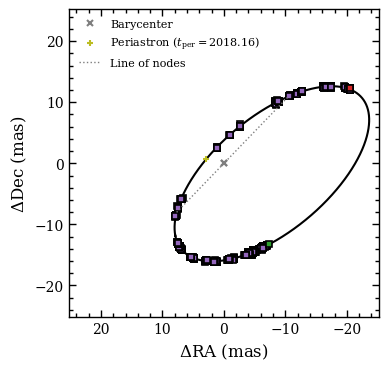

In [20]:
fig = results.plot_orbit(plot_file="plot.png")